
- dataset
	- https://universe.roboflow.com/zhejiang-af-university-j6jfz/go-chess-2
	- https://universe.roboflow.com/aleksei-gorovoi-gogamedn/go-game-detection
	- https://universe.roboflow.com/test-yyxee/go-game-detection-mfkll
	- https://universe.roboflow.com/testjh/go_board_detection

https://huggingface.co/PekingU/rtdetr_r18vd



In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from datasets import Dataset, DatasetDict, Image as HFImage

In [2]:
# Define paths to the raw datasets
RAW_DATA_DIR = Path("/Users/hadim/Data/moku/raw")

DATASETS = {
    "go_game_v10": RAW_DATA_DIR / "Go Game detection.v10i.coco",
    "go_game_v1": RAW_DATA_DIR / "Go game detection.v1i.coco",
    "go_chess": RAW_DATA_DIR / "go-chess 2.v3-go-chess.v1.coco",
}

# Verify all datasets exist
for name, path in DATASETS.items():
    exists = path.exists()
    print(f"{'✓' if exists else '✗'} {name}: {path.name}")

✓ go_game_v10: Go Game detection.v10i.coco
✓ go_game_v1: Go game detection.v1i.coco
✓ go_chess: go-chess 2.v3-go-chess.v1.coco


## Load COCO Annotations

Helper function to load and parse COCO format annotations.

In [3]:
def load_coco_dataset(dataset_path: Path) -> dict:
    """Load COCO annotations for all splits in a dataset."""
    splits = {}
    for split in ["train", "valid", "test"]:
        split_path = dataset_path / split
        ann_file = split_path / "_annotations.coco.json"

        if ann_file.exists():
            with open(ann_file) as f:
                data = json.load(f)

            # Add image paths
            for img in data["images"]:
                img["file_path"] = str(split_path / img["file_name"])

            splits[split] = data
            print(f"  {split}: {len(data['images'])} images, {len(data['annotations'])} annotations")

    return splits


def get_categories(coco_data: dict) -> dict:
    """Extract category id to name mapping."""
    return {cat["id"]: cat["name"] for cat in coco_data.get("categories", [])}


def summarize_annotations(coco_data: dict) -> dict:
    """Count annotations per category."""
    categories = get_categories(coco_data)
    counts = {name: 0 for name in categories.values()}

    for ann in coco_data.get("annotations", []):
        cat_id = ann["category_id"]
        if cat_id in categories:
            counts[categories[cat_id]] += 1

    return counts

In [4]:
# Load all datasets
all_datasets = {}

for name, path in DATASETS.items():
    print(f"\n📁 Loading {name}:")
    all_datasets[name] = load_coco_dataset(path)


📁 Loading go_game_v10:
  train: 241 images, 85751 annotations
  valid: 14 images, 4748 annotations
  test: 1 images, 364 annotations

📁 Loading go_game_v1:
  train: 230 images, 83926 annotations
  valid: 12 images, 4382 annotations
  test: 1 images, 364 annotations

📁 Loading go_chess:
  train: 206 images, 13079 annotations
  valid: 20 images, 1283 annotations
  test: 10 images, 558 annotations


## Explore Categories

Compare the categories across all datasets.

In [5]:
# Compare categories across datasets
print("Categories by dataset:\n")

for name, splits in all_datasets.items():
    # Get categories from train split (they should be the same across splits)
    train_data = splits.get("train", {})
    categories = train_data.get("categories", [])

    print(f"📁 {name}:")
    for cat in categories:
        print(f"   {cat['id']:2d}: {cat['name']}")
    print()

Categories by dataset:

📁 go_game_v10:
    0: go-game
    1: black_stone
    2: board
    3: board_corner
    4: empty
    5: empty_corner
    6: empty_edge
    7: white_stone

📁 go_game_v1:
    0: go-board
    1: black_stone
    2: board
    3: board_corner
    4: empty
    5: empty_corner
    6: empty_edge
    7: white_stone

📁 go_chess:
    0: go-stone-FMbU
    1: black_stone
    2: goboard
    3: white_stone



## Visualize Sample Images

Display sample images with bounding box annotations from each dataset.

In [8]:
# Color palette for categories
CATEGORY_COLORS = {
    "black_stone": "black",
    "white_stone": "white",
    "board": "brown",
    "board_corner": "orange",
    "empty": "gray",
    "empty_corner": "lightgray",
    "empty_edge": "silver",
    "go-game": "green",
}


def visualize_image(coco_data: dict, image_idx: int = 0, show_labels: bool = True):
    """Visualize an image with its bounding box annotations."""
    categories = get_categories(coco_data)
    images = coco_data["images"]
    annotations = coco_data["annotations"]

    # Get the image
    img_info = images[image_idx]
    img_id = img_info["id"]
    img_path = img_info["file_path"]

    # Get annotations for this image
    img_anns = [ann for ann in annotations if ann["image_id"] == img_id]

    # Load and display image
    img = Image.open(img_path)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.imshow(img)

    # Draw bounding boxes
    for ann in img_anns:
        x, y, w, h = ann["bbox"]
        cat_name = categories.get(ann["category_id"], "unknown")
        color = CATEGORY_COLORS.get(cat_name, "red")

        # Skip very small boxes for cleaner visualization
        if w < 5 or h < 5:
            continue

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)

        if show_labels:
            ax.text(
                x,
                y - 2,
                cat_name,
                fontsize=8,
                color=color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
            )

    ax.set_title(f"{img_info['file_name']} ({len(img_anns)} annotations)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return img_info, img_anns


Dataset: go_game_v10


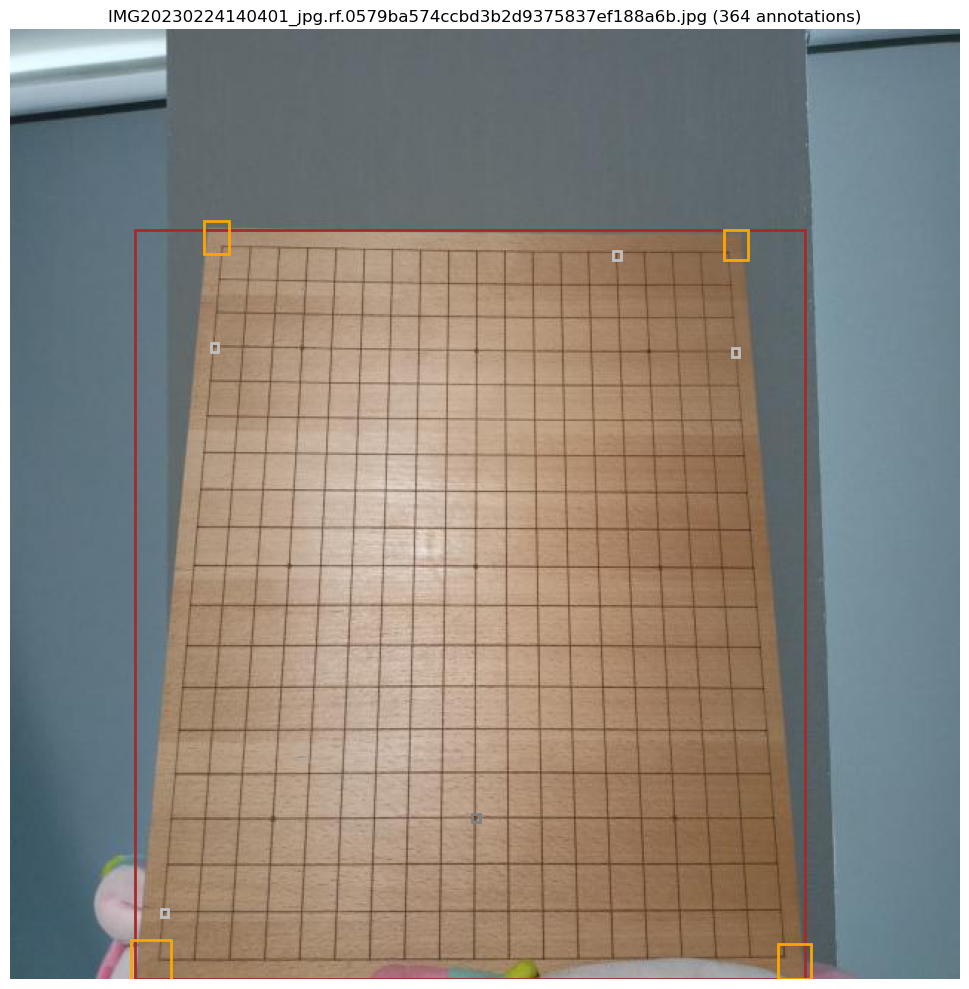


Dataset: go_game_v1


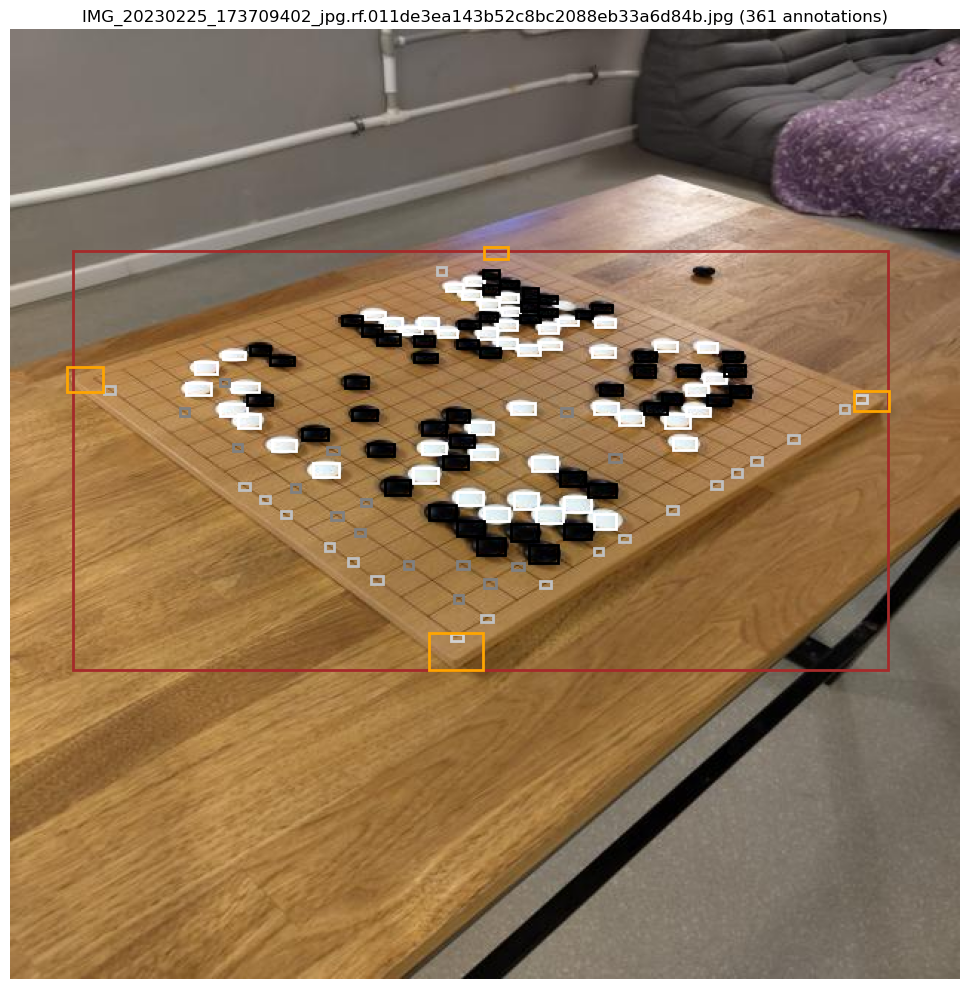


Dataset: go_chess


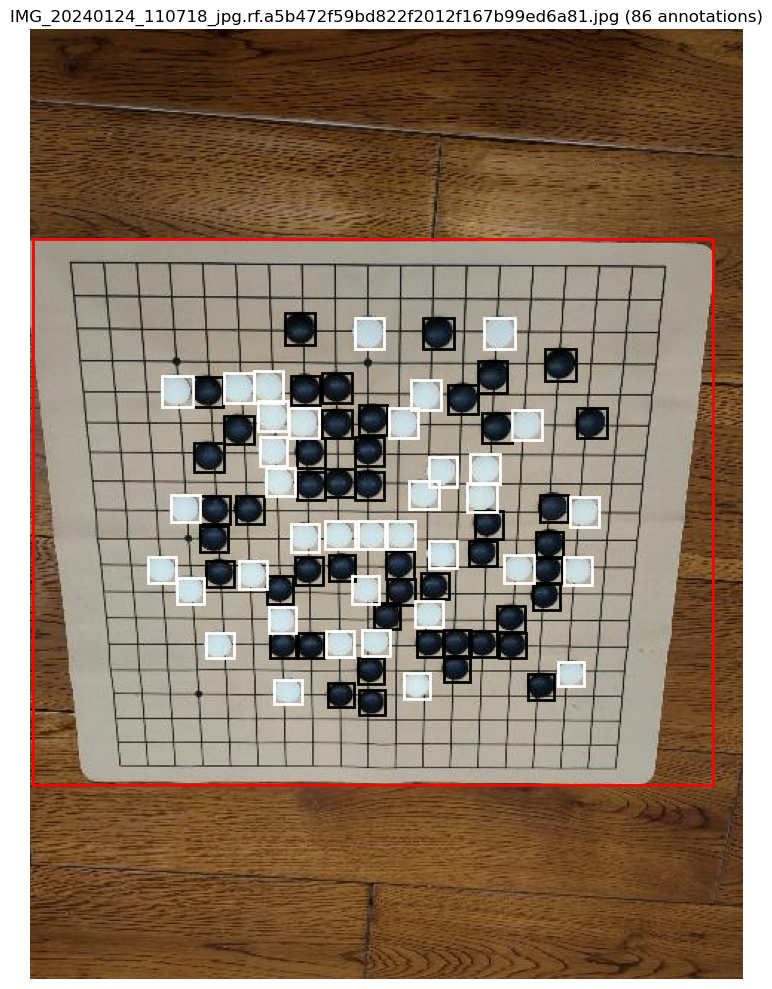

In [9]:
# Visualize a sample from each dataset
for name, splits in all_datasets.items():
    print(f"\n{'=' * 50}")
    print(f"Dataset: {name}")
    print(f"{'=' * 50}")

    train_data = splits.get("train", {})
    if train_data:
        # Show first image (only board-level annotations for clarity)
        visualize_image(train_data, image_idx=0, show_labels=False)

## Convert to Hugging Face Dataset

Convert COCO format data to a HuggingFace Dataset for easier manipulation and upload.

In [ ]:
def coco_to_hf_format(coco_data: dict, dataset_name: str) -> list[dict]:
    """Convert COCO format to HuggingFace object detection format.

    HuggingFace format for object detection:
    - image: PIL Image or path
    - objects: dict with 'bbox', 'category' lists

    COCO bbox format: [x_min, y_min, width, height]
    """
    categories = get_categories(coco_data)
    images = coco_data["images"]
    annotations = coco_data["annotations"]

    # Group annotations by image_id
    img_to_anns = {}
    for ann in annotations:
        img_id = ann["image_id"]
        if img_id not in img_to_anns:
            img_to_anns[img_id] = []
        img_to_anns[img_id].append(ann)

    # Build dataset rows
    rows = []
    for img_info in images:
        img_id = img_info["id"]
        img_anns = img_to_anns.get(img_id, [])

        # Extract bboxes and categories
        bboxes = []
        category_ids = []
        category_names = []
        areas = []

        for ann in img_anns:
            bboxes.append(ann["bbox"])  # [x, y, width, height]
            category_ids.append(ann["category_id"])
            category_names.append(categories.get(ann["category_id"], "unknown"))
            areas.append(ann.get("area", 0))

        rows.append(
            {
                "image_path": img_info["file_path"],
                "image_id": img_id,
                "width": img_info["width"],
                "height": img_info["height"],
                "source_dataset": dataset_name,
                "objects": {
                    "bbox": bboxes,
                    "category_id": category_ids,
                    "category": category_names,
                    "area": areas,
                },
            }
        )

    return rows


def create_hf_dataset(all_data: dict) -> DatasetDict:
    """Create a HuggingFace DatasetDict from all COCO datasets."""
    splits_data = {"train": [], "validation": [], "test": []}

    for dataset_name, splits in all_data.items():
        for split_name, coco_data in splits.items():
            # Map 'valid' to 'validation' for HF convention
            hf_split = "validation" if split_name == "valid" else split_name
            rows = coco_to_hf_format(coco_data, dataset_name)
            splits_data[hf_split].extend(rows)
            print(f"Added {len(rows)} samples from {dataset_name}/{split_name} to {hf_split}")

    # Create DatasetDict
    dataset_dict = {}
    for split_name, rows in splits_data.items():
        if rows:
            dataset_dict[split_name] = Dataset.from_list(rows)
            print(f"\n{split_name}: {len(rows)} total samples")

    return DatasetDict(dataset_dict)

In [ ]:
# Create the merged HuggingFace dataset
dataset = create_hf_dataset(all_datasets)
dataset

In [ ]:
# Inspect a sample
print("Sample from training set:")
sample = dataset["train"][0]
print(f"Image path: {sample['image_path']}")
print(f"Image size: {sample['width']}x{sample['height']}")
print(f"Source: {sample['source_dataset']}")
print(f"Number of objects: {len(sample['objects']['bbox'])}")
print(f"Categories present: {set(sample['objects']['category'])}")

## Dataset Statistics

Analyze the merged dataset to understand its composition.

In [ ]:
from collections import Counter


def compute_dataset_stats(ds):
    """Compute statistics for a dataset split."""
    all_categories = []
    sources = []
    total_objects = 0

    for sample in ds:
        all_categories.extend(sample["objects"]["category"])
        sources.append(sample["source_dataset"])
        total_objects += len(sample["objects"]["bbox"])

    return {
        "num_images": len(ds),
        "total_objects": total_objects,
        "avg_objects_per_image": total_objects / len(ds) if len(ds) > 0 else 0,
        "category_counts": Counter(all_categories),
        "source_counts": Counter(sources),
    }


# Compute stats for each split
for split_name, split_ds in dataset.items():
    stats = compute_dataset_stats(split_ds)

    print(f"\n{'=' * 50}")
    print(f"Split: {split_name}")
    print(f"{'=' * 50}")
    print(f"Images: {stats['num_images']}")
    print(f"Total objects: {stats['total_objects']:,}")
    print(f"Avg objects/image: {stats['avg_objects_per_image']:.1f}")

    print(f"\nBy source dataset:")
    for source, count in stats["source_counts"].most_common():
        print(f"  {source}: {count}")

    print(f"\nBy category:")
    for cat, count in stats["category_counts"].most_common():
        print(f"  {cat}: {count:,}")

## Next Steps

After exploration, the following steps will be needed:

1. **Category Harmonization**: Unify category names across datasets
2. **Data Cleaning**: Remove duplicates, fix annotation errors
3. **Upload to Hugging Face**: Push the clean dataset to HF Hub
4. **Training**: Fine-tune RT-DETR model on this dataset

```python
# Example: Upload to Hugging Face Hub
# dataset.push_to_hub("kaya-go/goban-detection", private=True)
```